In [1]:
import sys
sys.path.insert(0, 'pythonlib')

import pandas as pd
from enginewash import WashCalculator, FlightRecord, MaintenanceRecord, EGTHDM

# Записи о техническом обслуживании
# 223 — очистка коннекторов
# 224 — замена термопары
# 330-340 — промывка водой и растворами

# columns : engine_id, maint_datetime, ata_code, ata_classification, reason, creation_datetime
maintenance = pd.read_csv('https://storage.yandexcloud.net/ecm-data/ecmapp.maintenance_20260222.csv',
                          parse_dates=['creation_datetime', 'maint_datetime'])

# Отчеты, записанные в фазу круиза
# columns : ['aircraft_id', 'engine_position', 'flight_datetime', 'zpcn12', 'zpcn25',
    #    'zpoil', 'zt49', 'ztoil', 'zvb1f', 'zwf36', 'brat', 'degt', 'dpoil',
    #    'egtc', 'egthdm', 'gegtmc', 'gn2mc', 'gpcn25', 'gwfm', 'pcn12',
    #    'pcn12i', 'pcn1k', 'pcn2c', 'pip_bled', 'pip_etop', 'pip_oilm',
    #    'pip_pem', 'pip_vlcr', 'pip_xn1c', 'sloatl', 'wbi', 'wfmp', 'zpcn25_d',
    #    'zt49_d', 'zwf36_d', 'agw', 'ibe1', 'ibe2', 'ibp1', 'ibp2', 'ivs12',
    #    'sat', 'zalt', 'zt1a', 'zxm', 'engine_id', 'n1_modifier'],

data_cruise = pd.read_csv('https://storage.yandexcloud.net/ecm-data/s7.b737_cruise_20260222-merged.csv',
                           parse_dates=['flight_datetime'])

# Отчеты, записанные на взлете
data_takeoff  = pd.read_csv('https://storage.yandexcloud.net/ecm-data/s7.b737_takeoff_20260222-merged.csv',
                           parse_dates=['flight_datetime'])


In [19]:
# use engine wash library to calculate wash effects for takeoff (for EGTHDM parameter only)
wash_maint = maintenance[maintenance['ata_code'].astype(str).str.match(r'^3[34]\d$')]

takeoff = data_takeoff[['engine_id', 'flight_datetime', 'egthdm']].dropna()
takeoff = takeoff.assign(engine_id=takeoff['engine_id'].astype(int).astype(str))

flights = [
    FlightRecord(
        engine_id=row.engine_id,
        flight_datetime=row.flight_datetime,
        float_value=row.egthdm,
    )
    for row in takeoff.itertuples()
]

maintenance_records = [
    MaintenanceRecord(
        engine_id=str(row.engine_id),
        maint_datetime=row.maint_datetime.tz_localize(None),
        ata_code=str(row.ata_code),
    )
    for row in wash_maint[['engine_id', 'maint_datetime', 'ata_code']].itertuples()
]

calc = WashCalculator()
result = calc.process(flights=flights, maintenance=maintenance_records, parameter=EGTHDM)

result.df_event

/Users/bogdan-korzh/engine-wash/pythonlib/enginewash/calculator.py:141: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["float_value_smooth"] = df["float_value_smooth"].fillna(df["float_value"])


,engine_id,event_index,maint_datetime,ata_code,delta_EGTHDM_TAKEOFF,mean_EGTHDM_TAKEOFF_before_wash,mean_EGTHDM_TAKEOFF_after_wash,date_loe_EGTHDM_TAKEOFF,days_loe_EGTHDM_TAKEOFF
0,657287,1,2024-02-10 03:00:00,331,2.196078,31.747860,33.943937,2024-02-16 23:41:37,6.0
1,657287,2,2024-02-25 03:00:00,340,3.806452,30.990279,34.796731,2024-03-24 05:52:13,28.0
2,657287,3,2024-04-23 03:00:00,331,-1.164826,36.350939,35.186113,2024-04-23 06:33:13,0.0
3,657287,4,2024-09-28 03:00:00,330,-2.557268,39.625974,37.068706,2024-09-28 09:06:45,0.0
4,657287,5,2025-09-19 03:00:00,330,1.020144,35.024688,36.044832,2025-09-19 13:01:34,0.0
...,...,...,...,...,...,...,...,...,...
362,896809,6,2024-03-21 03:00:00,331,0.233885,36.727219,36.961105,2024-03-21 10:57:37,0.0
363,896809,7,2024-11-06 03:00:00,330,-0.463588,43.038522,42.574934,2024-11-06 05:42:05,0.0
364,896809,8,2025-03-01 03:00:00,331,6.311938,32.045482,38.357420,NaT,NaN
365,896809,9,2025-06-17 03:00:00,331,1.328209,37.769602,39.097811,2025-06-17 15:28:15,0.0


In [ ]:
result.events

In [ ]:
result.df

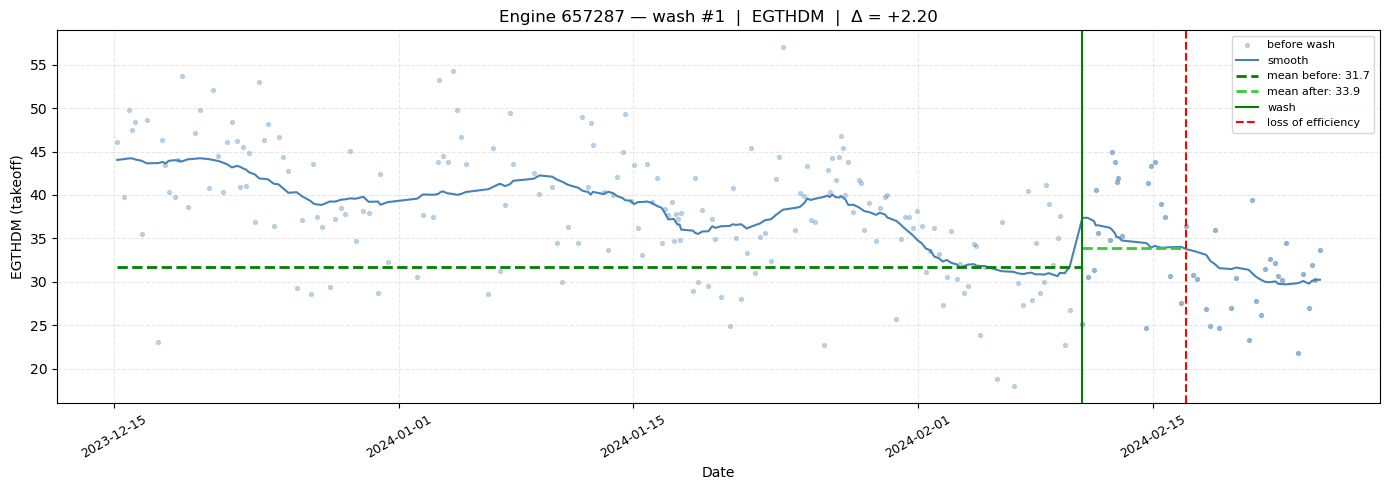

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_wash_event(df, engine_id, event_index):
    seg_mask = (df["engine_id"] == engine_id) & (df["event_cum"] == event_index)
    prev_mask = (df["engine_id"] == engine_id) & (df["event_cum"] == event_index - 1)
    seg = df[seg_mask].sort_values("flight_datetime")
    prev = df[prev_mask].sort_values("flight_datetime")

    _fig, ax = plt.subplots(figsize=(14, 5))

    # Raw scatter
    for part, label, alpha in [(prev, "before wash", 0.3), (seg, "after wash", 0.5)]:
        ax.scatter(part["flight_datetime"], part["float_value"],
                    s=8, color="steelblue", alpha=alpha, label=label if label == "before wash" else None)

    all_pts = pd.concat([prev, seg]).sort_values("flight_datetime")
    ax.plot(all_pts["flight_datetime"], all_pts["float_value_smooth_custom"],
            color="steelblue", linewidth=1.5, label="smooth")

    mean_before = seg["mean_before_wash"].iloc[0]
    mean_after  = seg["mean_after_wash"].iloc[0]
    time_loe    = seg["time_loss_of_efficiency"].iloc[0]
    _wash_time   = seg[seg["event"] == 1]["maint_datetime"].iloc[0] if (seg["event"] == 1).any() else seg["flight_datetime"].iloc[0]

    if prev["flight_datetime"].nunique() > 0:
        ax.hlines(mean_before, prev["flight_datetime"].min(), seg["flight_datetime"].min(),
                colors="green", linewidths=2, linestyles="--", label=f"mean before: {mean_before:.1f}")

    after_end = time_loe if pd.notna(time_loe) else seg["flight_datetime"].max()
    ax.hlines(mean_after, seg["flight_datetime"].min(), after_end,
            colors="limegreen", linewidths=2, linestyles="--", label=f"mean after: {mean_after:.1f}")

    ax.axvline(seg["flight_datetime"].iloc[0], color="green", linewidth=1.5, label="wash")
    # ax.axvline(wash_time, color="green", linewidth=1.5, label="wash")

    if pd.notna(time_loe):
        ax.axvline(time_loe, color="red", linewidth=1.5, linestyle="--", label="loss of efficiency")

    delta = seg["delta"].iloc[0]
    ax.set_title(f"Engine {engine_id} — wash #{event_index}  |  EGTHDM  |  Δ = {delta:+.2f}")
    ax.set_xlabel("Date")
    ax.set_ylabel("EGTHDM (takeoff)")

    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
    ax.tick_params(axis='x', which='major', labelsize=9)

    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, which='both', linestyle='--')
    plt.tight_layout()
    plt.show()


# Pick an engine and event with a detected loss of efficiency
example = result.df_event[result.df_event["date_loe_EGTHDM_TAKEOFF"].notna()].iloc[0]
plot_wash_event(result.df.query("flight_datetime >= '2023-12-15'"), example["engine_id"], example["event_index"])

1. Предусмотреть выбор критериев Время, часы (disabled), циклы (disabled)
2. Предусмотреть настройку конфигурации модуля (mean before, after, smooth window)
3. Настройка количества точек промывок (???) by date / __by point__
4. one vs multiple acnum selector
